<a id="top"></a> 
# Text Analysis Assessment Harry Potter Reviews

# Table of Contents 
1. [Business Understanding](#business-understanding) 
2. [Data Understanding](#data-understanding) 
3. [Baseline-Models](#baseline-models) 
4. [Data Preparation](#data-preparation) 
5. [Hyperparameter Tuning](#hyperparameter-tuning) 
6. [Evaluation](#evaluation) 
7. [References](#references) 
8. [Appendix](#appendix) 
<h2 id ="business-understanding">Business Understanding</h2> 
<a href="#top">Back to top</a>

<h2 id = "introduction">Introduction</h2>
<a href="#top">Back to top</a>
This is a text mining analysis of a Harry Potter Review dataset using Python. The notebook is structured in line with the CRISP-DM methodology. The main aim of the project is to classify unstructured review text into two sentiment categories. The written review comments are transformed into numerical feature representations and evaluated using multiple text mining techniques.

<h2 id="business-understanding">Business Understanding</h2>
<a href="#top">Back to top</a>

<h3 id="business-objective">Business Objective</h3>
<a href="#top">Back to top</a>

The objective of this project is to mine unstructured text data and build a text classification pipeline capable of telling the difference between positive and negative review sentiment.

<h3 id="project-aim">Project Aim</h3>
<a href="#top">Back to top</a>
The projects aim is to compare three baseline vectorisation techniques, apply a suitable clasification algorithm, explore the text through statistics and visualisations and iteratively improve performance through preprocessing, feature selection and hyperamerer tuning.

<h3 id="success-criteria">Success Criteria</h3>
<a href="#top">Back to top</a>
As sucessful outcome is a final text mining pipeline that produces strong and consistant cross-validation performance,that is supported by findings from data understanding and preparation.


In [286]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import warnings

from sklearn.svm import SVC
from sklearn.metrics import adjusted_rand_score, fowlkes_mallows_score
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

warnings.filterwarnings("ignore")

import text_mining_utils as tmu

In [287]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\B00156196\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\B00156196\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\B00156196\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\B00156196\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\B00156196\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

<h2 id="data-understanding">Data Understanding</h2>
<a href="#top">Back to top</a>

<h3 id="dataset-description">Dataset Description</h3>
<a href="#top">Back to top</a>
The dataset used in this analysis is a CSV file containing Harry Potter review data. The main text field is the (comment) column, which contains the unstructured review text. The (rating) column is used to derive binary class labels for the classification task.

<h3 id="initial-inspection">Initial Inspection</h3>
<a href="#top">Back to top</a>

The dataset is first loaded and inspected to identify its dimensions, available attributes, missing values, and general suitability for text mining.


In [288]:
data = pd.read_csv('HPotterReviews.csv')
print("Shape:", data.shape)

Shape: (491, 8)


In [289]:

print(data.head(5))
print(data.tail(10))
print(data.info)


   user_id user_sex  user_age user_country  rating  \
0        0   female        50      Germany     2.5   
1        1   female        23        Spain     4.0   
2        2     male        32       France     3.0   
3        3   female        24       Turkey     4.5   
4        4   female        40        Spain     5.0   

                                             comment favourite_character  \
0  "The transitions between scenes were awkward, ...       Severus Snape   
1   "Severus Snape's role adds an intriguing layer."       Severus Snape   
2  "The pacing was a bit slow, but the characters...         Ron Weasley   
3  "Hagrid's love for magical creatures is heartw...       Rubeus Hagrid   
4   "Neville Longbottom's courage is awe-inspiring."  Neville Longbottom   

         date  
0  27/12/2004  
1  22/11/2003  
2  16/09/2005  
3  17/09/2002  
4  17/10/2004  
     user_id user_sex  user_age user_country  rating  \
481      481     male        23       Sweden     4.5   
482      4

In [290]:
print("Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

Shape: (491, 8)

Columns:
['user_id', 'user_sex', 'user_age', 'user_country', 'rating', 'comment', 'favourite_character', 'date']


In [291]:
data.isnull().sum()

user_id                0
user_sex               0
user_age               0
user_country           0
rating                 0
comment                0
favourite_character    0
date                   0
dtype: int64

In [292]:
duplicate_count = data.duplicated(subset=['comment']).sum()
print("Duplicate comments:", duplicate_count)

Duplicate comments: 57


In [293]:
data = data.dropna(subset=['comment', 'rating'])
data = data.drop_duplicates(subset=['comment']).reset_index(drop=True)

print("Shape after removing missing values and duplicates:", data.shape)

Shape after removing missing values and duplicates: (434, 8)


<h3 id="label-creation">Label Creation</h3>
<a href="#top">Back to top</a>

To simplify the classification task, I created a binary sentiment label from the review rating. Reviews with a rating below 3.5 are labelled as negative, while reviews with a rating of 3.5 or above are labelled as positive. 

In [294]:
def make_label(rating):
    if rating >= 3.5:
        return "positive"
    else:
        return "negative"

data["label"] = data["rating"].apply(make_label)

data[["rating", "label"]].head()

,rating,label
0,2.5,negative
1,4.0,positive
2,3.0,negative
3,4.5,positive
4,5.0,positive


In [295]:
data["label"].value_counts()

label
positive    350
negative     84
Name: count, dtype: int64

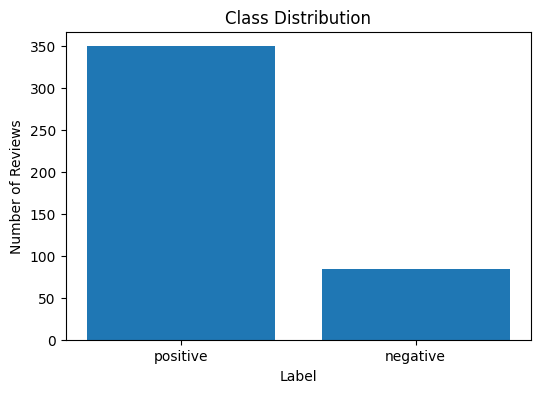

In [296]:
label_counts = data["label"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts.values)
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Reviews")
plt.show()

<h3 id="word-token-statistics">Word/Token Statistics</h3>
<a href="#top">Back to top</a>

Two types of token statistics are derived for each class in order to better understand the characteristics of the text. These statistics help identify differences in review length, vocabulary usage, and repitition across the positive and negative categories.

In [297]:
positive_docs = data.loc[data["label"] == "positive", "comment"].astype(str).tolist()
negative_docs = data.loc[data["label"] == "negative", "comment"].astype(str).tolist()

print("Positive documents:", len(positive_docs))
print("Negative documents:", len(negative_docs))

Positive documents: 350
Negative documents: 84


In [298]:
def get_token_stats(docs):
    tokenised_docs = [nltk.word_tokenize(doc) for doc in docs]
    all_tokens = [token for doc in tokenised_docs for token in doc]
    vocab = set(all_tokens)
    avg_doc_length = np.mean([len(doc) for doc in tokenised_docs])
    lexical_diversity = len(vocab) / len(all_tokens) if len(all_tokens) > 0 else 0
    
    return {
        "documents": len(docs),
        "total_tokens": len(all_tokens),
        "vocabulary_size": len(vocab),
        "average_document_length": round(avg_doc_length, 2),
        "lexical_diversity": round(lexical_diversity, 4)
    }

In [299]:
positive_stats = get_token_stats(positive_docs)
negative_stats = get_token_stats(negative_docs)

stats_df = pd.DataFrame([positive_stats, negative_stats], index=["positive", "negative"])
stats_df

,documents,total_tokens,vocabulary_size,average_document_length,lexical_diversity
positive,350,4037,494,11.53,0.1224
negative,84,1059,244,12.61,0.2304


The first statistic examined is the average document length, which indicated whether one class tends to contain longer reviews than the other. The second statistic is lexical diversity, this shows how varied the vocabulary is within each class. Together, these measures help indicate whether one category is more repetitive, more descriptive, or more linguistically varied than the other. 

<h3 id="frequent-terms">Frequent Terms by Category</h3>
<a href="#top">Back to top</a>

To identify the most common tokens in each category, the combined text for each class is examined. This helps highlight repeated concepts, possible stop words, and candidate terms for later preprocessing.

In [300]:
#join the documents into a single string for each class
positive_text = " ".join(positive_docs)
negative_text = " ".join(negative_docs)

In [301]:
# Print the 15 most frequent words for each class
tmu.print_n_mostFrequent("positive", positive_text, 15)
print()
tmu.print_n_mostFrequent("negative", negative_text, 15)

=== 15 most frequent tokens in positive ===
	Frequency of "``" is: 0.08669804310131285
	Frequency of "''" is: 0.08669804310131285
	Frequency of "." is: 0.0849640822392866
	Frequency of "'s" is: 0.043596730245231606
	Frequency of "the" is: 0.03963339113202873
	Frequency of "The" is: 0.03814713896457766
	Frequency of "is" is: 0.0255139955412435
	Frequency of "and" is: 0.01808273470398811
	Frequency of "of" is: 0.01684419123111221
	Frequency of "a" is: 0.015853356452811492
	Frequency of "to" is: 0.015357939063661135
	Frequency of "magical" is: 0.015110230369085955
	Frequency of "film" is: 0.012880852117909338
	Frequency of "character" is: 0.0121377260341838
	Frequency of "world" is: 0.010403765172157542

=== 15 most frequent tokens in negative ===
	Frequency of "``" is: 0.07932011331444759
	Frequency of "''" is: 0.07932011331444759
	Frequency of "." is: 0.07837582625118036
	Frequency of "and" is: 0.05004721435316336
	Frequency of "The" is: 0.044381491973559964
	Frequency of "'s" is: 0.043

In [302]:
from collections import Counter

def most_frequent_df(text, n=15):
    tokens = nltk.word_tokenize(text)
    counter = Counter(tokens)
    top_n = counter.most_common(n)
    df = pd.DataFrame(top_n, columns=["token", "count"])
    df["relative_frequency"] = df["count"] / len(tokens)
    return df

positive_freq_df = most_frequent_df(positive_text, 15)
negative_freq_df = most_frequent_df(negative_text, 15)

positive_freq_df

,token,count,relative_frequency
0,``,350,0.086698
1,'',350,0.086698
2,.,343,0.084964
3,'s,176,0.043597
4,the,160,0.039633
5,The,154,0.038147
6,is,103,0.025514
7,and,73,0.018083
8,of,68,0.016844
9,a,64,0.015853


In [303]:
#Display the negative version too
negative_freq_df

,token,count,relative_frequency
0,``,84,0.079320
1,'',84,0.079320
2,.,83,0.078376
3,and,53,0.050047
4,The,47,0.044381
5,'s,46,0.043437
6,the,41,0.038716
7,",",25,0.023607
8,character,21,0.019830
9,was,15,0.014164


<h3 id="visual-analysis">Visual Analysis</h3>
<a href="#top">Back to top</a>

Two visualisation technoques are used to examine the text by class:
1. bar charts displaying the most frquent terms and 
2. word clouds.
These help identify common concepts, repeated vocabulary, possible stop words, and word variations that may influence later preparation steps.

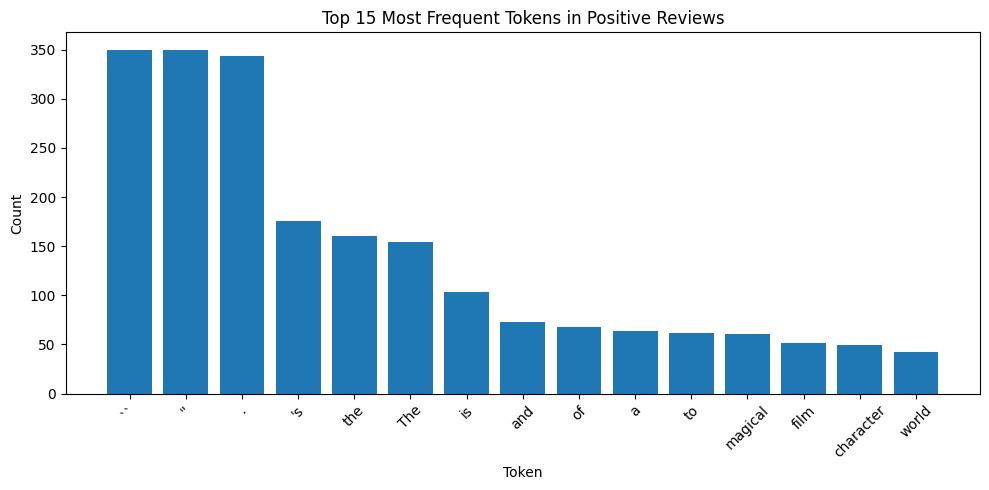

In [304]:
#Bar chart for positive review
plt.figure(figsize=(10,5))#Bar chart for positive review
plt.bar(positive_freq_df["token"], positive_freq_df["count"])
plt.title("Top 15 Most Frequent Tokens in Positive Reviews")
plt.xlabel("Token")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

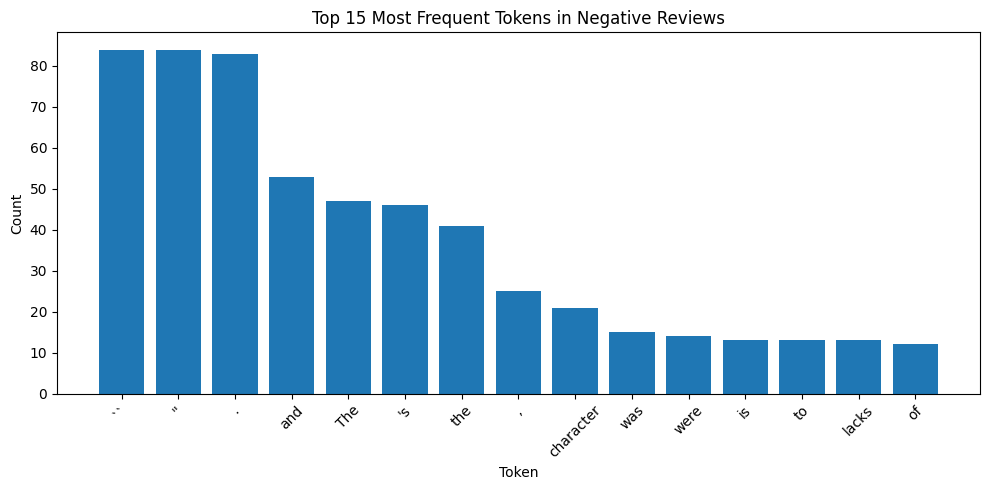

In [305]:
#Bar chart for negative review
plt.figure(figsize=(10,5))
plt.bar(negative_freq_df["token"], negative_freq_df["count"])
plt.title("Top 15 Most Frequent Tokens in Negative Reviews")
plt.xlabel("Token")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

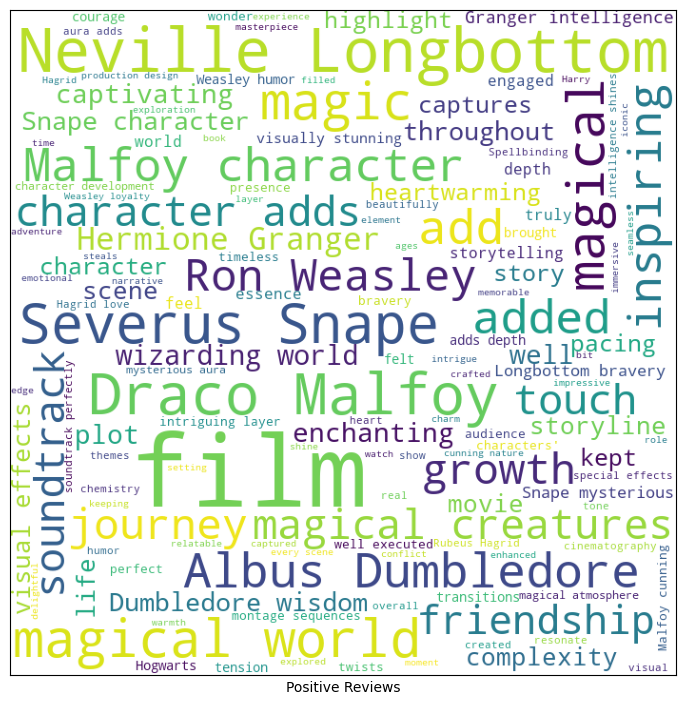

In [306]:
#Word clouds for positive reviews
tmu.generate_cloud(positive_text, "Positive Reviews", bg_colour="white", min_font=10)
plt.show()

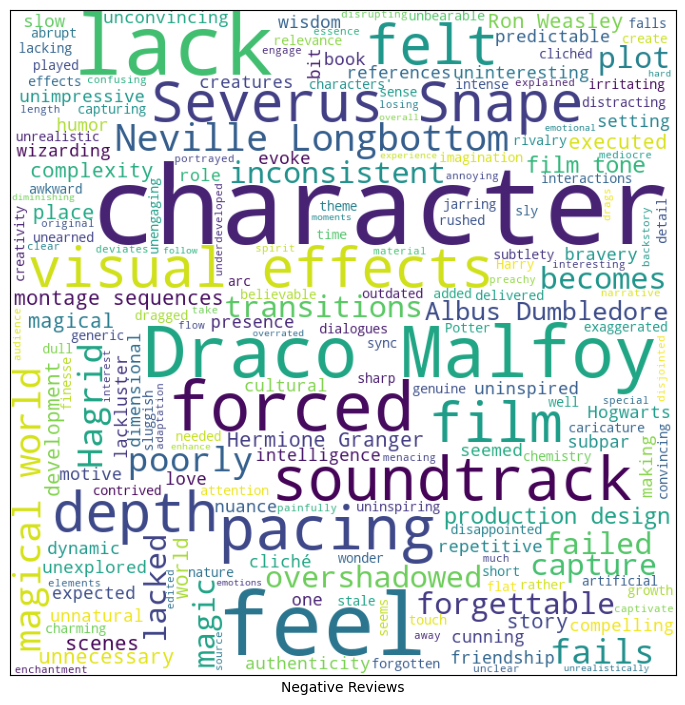

In [307]:
#Word clouds for negative reviews
tmu.generate_cloud(negative_text, "Negative Reviews", bg_colour="white", min_font=10)
plt.show()

The bar charts and word clouds are used to identify the most common terms in each category. These outputs will be examined to detremine whether there are obvious repeated function words, possible stop words, or variations of similar concepts that should be handled during preprocessing. They also help identify terms that may later become strong predictive features.

<h2 id="baseline-models">Baseline Models</h2>
<a href="#top">Back to top</a>

Following the data understanding stage, the next step is to establish baseline models for the classification task. This involves converting the raw review text into numerical feature representations that can be used by a machine learning algorithm. 

<h3 id="baseline-matrix-count">Baseline Matrix 1: Count Matrix</h3>
<a href="#top">Back to top</a>
The first baseline representation is a count matrix. This records how many times each token appears in each document and provides a simple Bag of Words style representation of the corpus.

In [308]:
baseline_count_matrix = tmu.build_matrix(data.comment, is_count=True)
baseline_count_matrix.head()

,!,"""",',",",-,.,;,A,Albus,An,...,witness,wizarding,wizardry,wonder,wonderful,wondrous,world,worth,writing,you
0,0,2,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,2,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,2,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,2,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,2,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [309]:
print("Count matrix shape:", baseline_count_matrix.shape)

Count matrix shape: (434, 621)


<h3 id="baseline-matrix-tf">Baseline Matrix 2: Term Frequency Matrix</h3>
<a href="#top">Back to top</a>
The second baseline representation is a term frequency (TF) matrix. Unlike raw counts, this representation normalises token frequency relative to document length, which helps reduce the effect of longer documents containing naturally higher word counts.

In [310]:
baseline_tf_matrix = tmu.build_matrix(data.comment, use_idf=False)
baseline_tf_matrix.head()

,!,"""",',",",-,.,;,A,Albus,An,...,witness,wizarding,wizardry,wonder,wonderful,wondrous,world,worth,writing,you
0,0.0,0.485071,0.0,0.242536,0.000000,0.242536,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.577350,0.0,0.000000,0.000000,0.288675,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.485071,0.0,0.242536,0.000000,0.242536,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.577350,0.0,0.000000,0.000000,0.288675,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.577350,0.0,0.000000,0.288675,0.288675,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [311]:
print("TF matrix shape:", baseline_tf_matrix.shape)

TF matrix shape: (434, 621)


<h3 id="baseline-matrix-tfidf">Baseline Matrix 3: TF-IDF Matrix</h3>
<a href="#top">Back to top</a>

The third baseline representation is a TF-IDF matrix. This assigns greater weight to terms that are important within a document but less common across the whole corpus. It is often useful in text mining because it reduces the influence of very common words.

In [312]:
baseline_tfidf_matrix = tmu.build_matrix(data.comment)
baseline_tfidf_matrix.head()

,!,"""",',",",-,.,;,A,Albus,An,...,witness,wizarding,wizardry,wonder,wonderful,wondrous,world,worth,writing,you
0,0.0,0.141348,0.0,0.223565,0.000000,0.072152,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.172755,0.0,0.000000,0.000000,0.088183,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.136414,0.0,0.215761,0.000000,0.069633,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.186468,0.0,0.000000,0.000000,0.095183,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.181620,0.0,0.000000,0.319651,0.092708,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [313]:
print("TF-IDF matrix shape:", baseline_tfidf_matrix.shape)

TF-IDF matrix shape: (434, 621)


In [314]:
matrix_dims = pd.DataFrame({
    "Matrix": ["Count", "TF", "TF-IDF"],
    "Rows (documents)": [
        baseline_count_matrix.shape[0],
        baseline_tf_matrix.shape[0],
        baseline_tfidf_matrix.shape[0]
    ],
    "Columns (features)": [
        baseline_count_matrix.shape[1],
        baseline_tf_matrix.shape[1],
        baseline_tfidf_matrix.shape[1]
    ]
})

matrix_dims


,Matrix,Rows (documents),Columns (features)
0,Count,434,621
1,TF,434,621
2,TF-IDF,434,621


The three baseline matrices have the same number of documents but may differ in how feature values are represented. The count matrix stores raw token counts, the TF matrix normalises these counts by document length, and the TF-IDF matrix downweights terms that occur frequently across many documents. These differences may affect how well the classification algorithm can distinguish between the two classes.

<h3 id="classification-algorithm">Classification Algorithm</h3>
<a href="#top">Back to top</a>

Support Vector Classification (SVC) was selected as the classification algorithm for the baseline experiments. This method is suitable for text mining because vectorised text data is typically high-dimensional and sparse. SVC is effective at separating classes in such feature spaces and is widely used in document and sentiment classification tasks.

In [315]:
clf = SVC(random_state=43)
y = data.label

<h3 id="baseline-performance">Baseline Performance using Cross Validation</h3>
<a href="#top">Back to top</a>

The same classification algorithm is applied to each baseline matrix using cross-validation. This provides a fair comparison of the three text representations and establishes an initial benchmark before any further data preparation is introduced.

In [316]:
print("=== Count Matrix Classification Report ===")
tmu.printClassifReport(clf, baseline_count_matrix, y)

=== Count Matrix Classification Report ===
              precision    recall  f1-score   support

    negative       0.96      0.31      0.47        84
    positive       0.86      1.00      0.92       350

    accuracy                           0.86       434
   macro avg       0.91      0.65      0.70       434
weighted avg       0.88      0.86      0.83       434



In [317]:
print("=== TF Matrix Classification Report ===")
tmu.printClassifReport(clf, baseline_tf_matrix, y)

=== TF Matrix Classification Report ===
              precision    recall  f1-score   support

    negative       0.96      0.32      0.48        84
    positive       0.86      1.00      0.92       350

    accuracy                           0.87       434
   macro avg       0.91      0.66      0.70       434
weighted avg       0.88      0.87      0.84       434



In [318]:
print("=== TF-IDF Matrix Classification Report ===")
tmu.printClassifReport(clf, baseline_tfidf_matrix, y)

=== TF-IDF Matrix Classification Report ===
              precision    recall  f1-score   support

    negative       1.00      0.27      0.43        84
    positive       0.85      1.00      0.92       350

    accuracy                           0.86       434
   macro avg       0.93      0.64      0.67       434
weighted avg       0.88      0.86      0.83       434



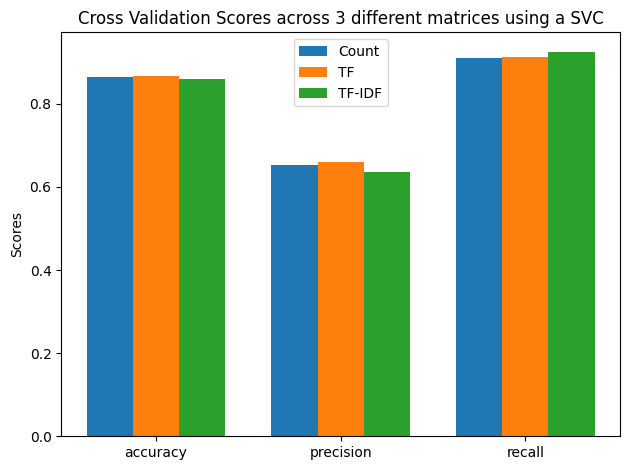

In [319]:
tmu.plot_avg_performance_for_3matrices(
    clf=clf,
    clf_name="SVC",
    matrices=[baseline_count_matrix, baseline_tf_matrix, baseline_tfidf_matrix],
    matrices_names=["Count", "TF", "TF-IDF"],
    y=y,
    cv=5
)

#simple 2 cluster model first

In [320]:
kmeans_model, cluster_labels, cluster_centers = tmu.k_means_clustering(
    baseline_tfidf_matrix,
    k=2,
    initialisation='random'
)

print("Cluster labels:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Cluster labels:
0    328
1    106
Name: count, dtype: int64


In [321]:
#Compare cluster labels 
cluster_results = data[["label"]].copy()
cluster_results["cluster"] = cluster_labels
cluster_results.head()

,label,cluster
0,negative,0
1,positive,1
2,negative,0
3,positive,0
4,positive,1


In [322]:
#cross-tabulation of true labels vs cluster labels
cluster_crosstab = pd.crosstab(cluster_results["label"], cluster_results["cluster"])
cluster_crosstab

cluster,0,1
label,,
negative,63,21
positive,265,85


In [323]:
# External clustering evaluation metrics:
ari = adjusted_rand_score(data["label"], cluster_labels)
fmi = fowlkes_mallows_score(data["label"], cluster_labels)

print("Adjusted Rand Index:", round(ari, 4))
print("Fowlkes-Mallows Score:", round(fmi, 4))

Adjusted Rand Index: 0.0019
Fowlkes-Mallows Score: 0.6586


In [324]:
cluster_crosstab = pd.crosstab(
    cluster_results["label"],
    cluster_results["cluster"],
    rownames=["True Label"],
    colnames=["Cluster"]
)

cluster_crosstab

Cluster,0,1
True Label,,
negative,63,21
positive,265,85


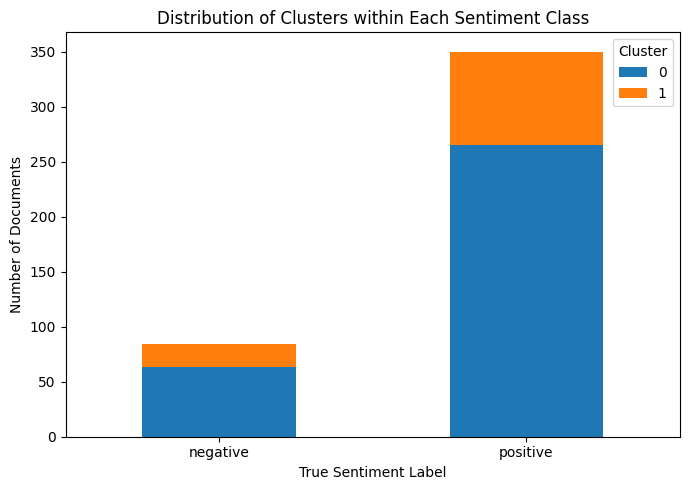

In [325]:
cluster_crosstab.plot(kind="bar", stacked=True, figsize=(7,5))
plt.title("Distribution of Clusters within Each Sentiment Class")
plt.xlabel("True Sentiment Label")
plt.ylabel("Number of Documents")
plt.xticks(rotation=0)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [326]:
# Evaluate the number of clusters (k) from 2 to 6
k_values = [2, 3, 4, 5, 6]

k_results = []

for k in k_values:
    model, labels, centers = tmu.k_means_clustering(baseline_tfidf_matrix, k=k, initialisation='random')
    
    ari = adjusted_rand_score(data["label"], labels)
    fmi = fowlkes_mallows_score(data["label"], labels)
    ch = calinski_harabasz_score(baseline_tfidf_matrix, labels)
    db = davies_bouldin_score(baseline_tfidf_matrix, labels)
    
    k_results.append({
        "k": k,
        "ARI": round(ari, 4),
        "FMI": round(fmi, 4),
        "Calinski-Harabasz": round(ch, 4),
        "Davies-Bouldin": round(db, 4)
    })

k_results_df = pd.DataFrame(k_results)
k_results_df

,k,ARI,FMI,Calinski-Harabasz,Davies-Bouldin
0,2,0.0019,0.6586,11.6992,5.1507
1,3,-0.0105,0.5588,11.1779,4.9713
2,4,0.0285,0.4931,9.7283,5.0762
3,5,0.0196,0.4846,10.0674,4.7328
4,6,0.0305,0.4491,9.3757,4.4475


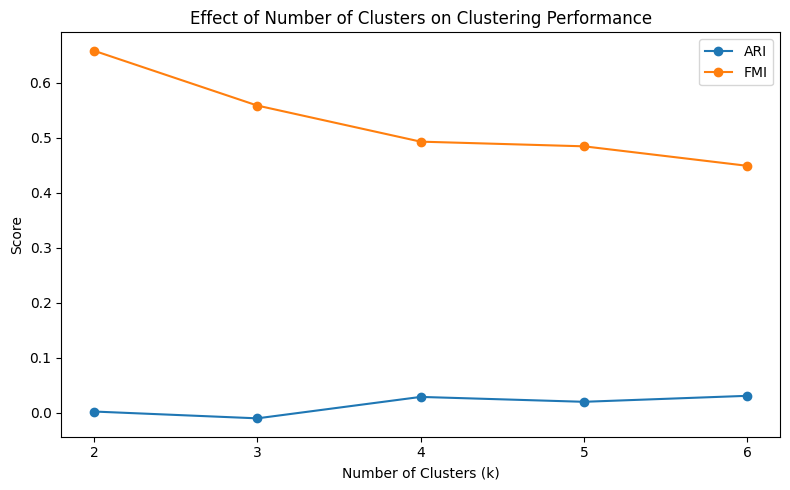

In [327]:
plt.figure(figsize=(8,5))
plt.plot(k_results_df["k"], k_results_df["ARI"], marker='o', label="ARI")
plt.plot(k_results_df["k"], k_results_df["FMI"], marker='o', label="FMI")
plt.title("Effect of Number of Clusters on Clustering Performance")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

In [328]:
#Compare random and k-means++
init_methods = ["random", "k-means++"]

init_results = []

for init_method in init_methods:
    model, labels, centers = tmu.k_means_clustering(
        baseline_tfidf_matrix,
        k=2,
        initialisation=init_method
    )
    
    ari = adjusted_rand_score(data["label"], labels)
    fmi = fowlkes_mallows_score(data["label"], labels)
    ch = calinski_harabasz_score(baseline_tfidf_matrix, labels)
    db = davies_bouldin_score(baseline_tfidf_matrix, labels)
    
    init_results.append({
        "initialisation": init_method,
        "ARI": round(ari, 4),
        "FMI": round(fmi, 4),
        "Calinski-Harabasz": round(ch, 4),
        "Davies-Bouldin": round(db, 4)
    })

init_results_df = pd.DataFrame(init_results)
init_results_df

,initialisation,ARI,FMI,Calinski-Harabasz,Davies-Bouldin
0,random,0.0019,0.6586,11.6992,5.1507
1,k-means++,-0.0007,0.5941,10.5625,6.2873


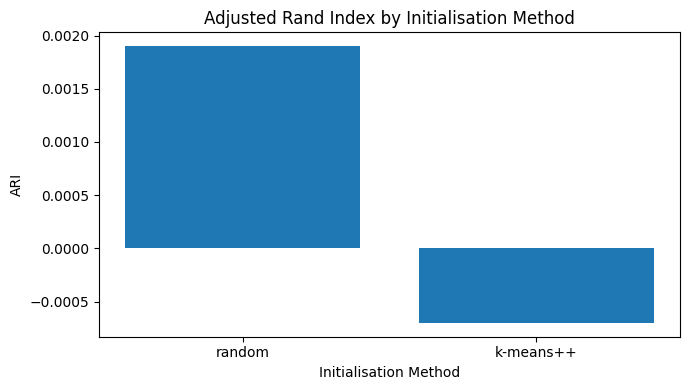

In [329]:
plt.figure(figsize=(7,4))
plt.bar(init_results_df["initialisation"], init_results_df["ARI"])
plt.title("Adjusted Rand Index by Initialisation Method")
plt.xlabel("Initialisation Method")
plt.ylabel("ARI")
plt.tight_layout()

plt.show()

<h2 id="data-preparation">Data Preparation</h2>
<a href="#top">Back to top</a>

<h3 id="preprocessing-technique-1">Preprocessing Technique 1: Punctuation Removal</h3>
<a href="#top">Back to top</a>

The first preprocessing technique applied was punctuation removal. This was selected because punctuation marks appeared as tokens during the data understanding stage and were considered unlikely to contribute useful predictive information for sentiment classification.

In [330]:
def remove_punctuation_regex(text):
    return re.sub(r"[^\w\s']", " ", str(text))

In [331]:
data["comment_no_punct"] = data["comment"].apply(remove_punctuation_regex)
data[["comment", "comment_no_punct"]].head()

,comment,comment_no_punct
0,"""The transitions between scenes were awkward, ...",The transitions between scenes were awkward ...
1,"""Severus Snape's role adds an intriguing layer.""",Severus Snape's role adds an intriguing layer
2,"""The pacing was a bit slow, but the characters...",The pacing was a bit slow but the characters...
3,"""Hagrid's love for magical creatures is heartw...",Hagrid's love for magical creatures is heartw...
4,"""Neville Longbottom's courage is awe-inspiring.""",Neville Longbottom's courage is awe inspiring


In [332]:
#Count
count_no_punct = tmu.build_matrix(data.comment_no_punct, is_count=True)
print("Count matrix shape after punctuation removal:", count_no_punct.shape)

Count matrix shape after punctuation removal: (434, 615)


In [333]:
#TF
tf_no_punct = tmu.build_matrix(data.comment_no_punct, use_idf=False)
print("TF matrix shape after punctuation removal:", tf_no_punct.shape)

TF matrix shape after punctuation removal: (434, 615)


In [334]:
#TF-IDF
tfidf_no_punct = tmu.build_matrix(data.comment_no_punct)
print("TF-IDF matrix shape after punctuation removal:", tfidf_no_punct.shape)


TF-IDF matrix shape after punctuation removal: (434, 615)


Evaluate performance after punctuation removal

In [335]:
print("=== Count Matrix After Punctuation Removal ===")
tmu.printClassifReport(clf, count_no_punct, y)

print("=== TF Matrix After Punctuation Removal ===")
tmu.printClassifReport(clf, tf_no_punct, y)

print("=== TF-IDF Matrix After Punctuation Removal ===")
tmu.printClassifReport(clf, tfidf_no_punct, y)

=== Count Matrix After Punctuation Removal ===
              precision    recall  f1-score   support

    negative       1.00      0.31      0.47        84
    positive       0.86      1.00      0.92       350

    accuracy                           0.87       434
   macro avg       0.93      0.65      0.70       434
weighted avg       0.89      0.87      0.84       434

=== TF Matrix After Punctuation Removal ===
              precision    recall  f1-score   support

    negative       1.00      0.31      0.47        84
    positive       0.86      1.00      0.92       350

    accuracy                           0.87       434
   macro avg       0.93      0.65      0.70       434
weighted avg       0.89      0.87      0.84       434

=== TF-IDF Matrix After Punctuation Removal ===
              precision    recall  f1-score   support

    negative       1.00      0.25      0.40        84
    positive       0.85      1.00      0.92       350

    accuracy                           0.85

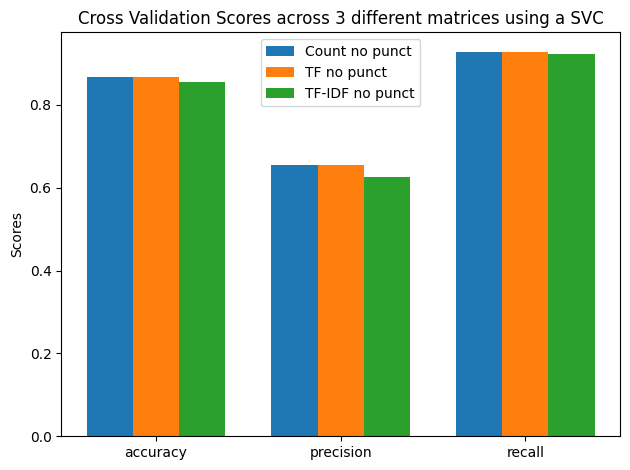

In [336]:
#Comparison Chart
tmu.plot_avg_performance_for_3matrices(
    clf=clf,
    clf_name="SVC",
    matrices=[count_no_punct, tf_no_punct, tfidf_no_punct],
    matrices_names=["Count no punct", "TF no punct", "TF-IDF no punct"],
    y=y,
    cv=5
)

In [337]:
#Comparison Table
punct_dims = pd.DataFrame({
    "Matrix": ["Count no punct", "TF no punct", "TF-IDF no punct"],
    "Rows (documents)": [
        count_no_punct.shape[0],
        tf_no_punct.shape[0],
        tfidf_no_punct.shape[0]
    ],
    "Columns (features)": [
        count_no_punct.shape[1],
        tf_no_punct.shape[1],
        tfidf_no_punct.shape[1]
    ]
})

punct_dims

,Matrix,Rows (documents),Columns (features)
0,Count no punct,434,615
1,TF no punct,434,615
2,TF-IDF no punct,434,615


<h3 id="preprocessing-technique-2">Preprocessing Technique 2: Stopword Removal</h3>
<a href="#top">Back to top</a>
The second preprocessing technique applied was stopword removal. This was selected because the data understanding stage showed that several very common words appeared frequently across the corpus. These words were unlikely to contribute strong predictive value for sentiment classification and were therefore removed in order to reduce noise and improve the quality of the feature space.

In [338]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [339]:
data["comment_no_punct_sw"] = data["comment_no_punct"].apply(
    lambda x: tmu.remove_sw_punct(x, stop_words)
)

data[["comment_no_punct", "comment_no_punct_sw"]].head()

,comment_no_punct,comment_no_punct_sw
0,The transitions between scenes were awkward ...,The transitions scenes awkward soundtrack forg...
1,Severus Snape's role adds an intriguing layer,Severus Snape 's role adds intriguing layer
2,The pacing was a bit slow but the characters...,The pacing bit slow characters charming
3,Hagrid's love for magical creatures is heartw...,Hagrid 's love magical creatures heartwarming
4,Neville Longbottom's courage is awe inspiring,Neville Longbottom 's courage awe inspiring


In [340]:
#Count
count_no_punct_sw = tmu.build_matrix(data.comment_no_punct_sw, is_count=True)
print("Count matrix shape after punctuation + stopword removal:", count_no_punct_sw.shape)

Count matrix shape after punctuation + stopword removal: (434, 555)


In [341]:
#TF
tf_no_punct_sw = tmu.build_matrix(data.comment_no_punct, use_idf=False)
print("TF matrix shape after punctuation removal:", tf_no_punct.shape)

TF matrix shape after punctuation removal: (434, 615)


In [342]:
#TF -IDF
tfidf_no_punct_sw = tmu.build_matrix(data.comment_no_punct_sw)
print("TF-IDF matrix shape after punctuation + stopword removal:", tfidf_no_punct_sw.shape)


TF-IDF matrix shape after punctuation + stopword removal: (434, 555)


In [343]:
print("=== Count Matrix After Punctuation + Stopword Removal ===")
tmu.printClassifReport(clf, count_no_punct_sw, y)

print("=== TF Matrix After Punctuation + Stopword Removal ===")
tmu.printClassifReport(clf, tf_no_punct_sw, y)

print("=== TF-IDF Matrix After Punctuation + Stopword Removal ===")
tmu.printClassifReport(clf, tfidf_no_punct_sw, y)

=== Count Matrix After Punctuation + Stopword Removal ===
              precision    recall  f1-score   support

    negative       1.00      0.15      0.27        84
    positive       0.83      1.00      0.91       350

    accuracy                           0.84       434
   macro avg       0.92      0.58      0.59       434
weighted avg       0.86      0.84      0.78       434

=== TF Matrix After Punctuation + Stopword Removal ===
              precision    recall  f1-score   support

    negative       1.00      0.31      0.47        84
    positive       0.86      1.00      0.92       350

    accuracy                           0.87       434
   macro avg       0.93      0.65      0.70       434
weighted avg       0.89      0.87      0.84       434

=== TF-IDF Matrix After Punctuation + Stopword Removal ===
              precision    recall  f1-score   support

    negative       1.00      0.13      0.23        84
    positive       0.83      1.00      0.91       350

    accura

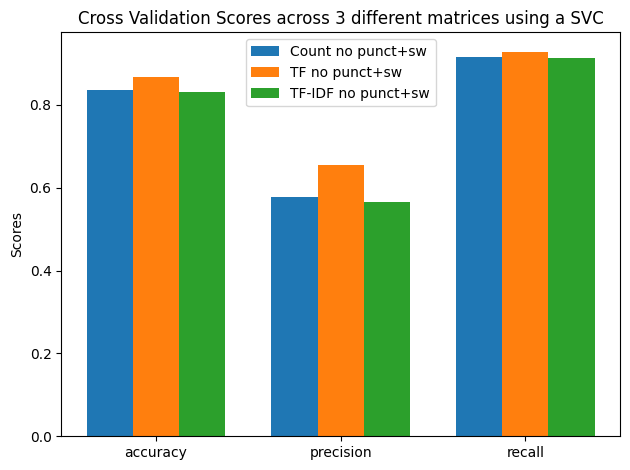

In [344]:
#Compare performance before and after punctuation removal
tmu.plot_avg_performance_for_3matrices(
    clf=clf,
    clf_name="SVC",
    matrices=[count_no_punct_sw, tf_no_punct_sw, tfidf_no_punct_sw],
    matrices_names=["Count no punct+sw", "TF no punct+sw", "TF-IDF no punct+sw"],
    y=y,
    cv=5
)

<h3 id="feature-selection-technique-1">Feature Selection Technique 1: Statistical Univariate Selection</h3>
<a href="#top">Back to top</a>

In [345]:
stopword_dims = pd.DataFrame({
    "Matrix": ["Count no punct+sw", "TF no punct+sw", "TF-IDF no punct+sw"],
    "Rows (documents)": [
        count_no_punct_sw.shape[0],
        tf_no_punct_sw.shape[0],
        tfidf_no_punct_sw.shape[0]
    ],
    "Columns (features)": [
        count_no_punct_sw.shape[1],
        tf_no_punct_sw.shape[1],
        tfidf_no_punct_sw.shape[1]
    ]
})

stopword_dims

,Matrix,Rows (documents),Columns (features)
0,Count no punct+sw,434,555
1,TF no punct+sw,434,615
2,TF-IDF no punct+sw,434,555


<h3 id="feature-selection-technique-1">Feature Selection Technique 1: Statistical Univariate Selection</h3>
<a href="#top">Back to top</a>

The first feature selection technique applied was statistical univariate selection.

In [346]:
from sklearn.feature_selection import chi2

In [347]:
fs1_scores, tfidf_fs1 = tmu.stat_univariate_fs(
    X=tfidf_no_punct_sw,
    y=y,
    weight_method=chi2,
    selection_method='fpr',
    param=0.05
)

print("Original TF-IDF shape:", tfidf_no_punct_sw.shape)
print("Reduced TF-IDF shape after univariate selection:", tfidf_fs1.shape)

Original TF-IDF shape: (434, 555)
Reduced TF-IDF shape after univariate selection: (434, 28)


In [348]:
fs1_scores.sort_values(by="Weight", ascending=False).head(20)

,Attribute,Weight,p-value
313,lacks,21.221579,0.000004
247,forced,15.304335,0.000092
224,fails,8.868477,0.002901
248,forgettable,8.861270,0.002913
375,overshadowed,8.622776,0.003320
388,poorly,8.498968,0.003553
283,inconsistent,7.795426,0.005238
223,failed,7.762529,0.005334
94,capture,7.647189,0.005686
232,feels,7.474685,0.006257


In [349]:
print("=== TF-IDF Matrix After Univariate Feature Selection (chi2) ===")
tmu.printClassifReport(clf, tfidf_fs1, y)

=== TF-IDF Matrix After Univariate Feature Selection (chi2) ===
              precision    recall  f1-score   support

    negative       0.96      0.79      0.86        84
    positive       0.95      0.99      0.97       350

    accuracy                           0.95       434
   macro avg       0.95      0.89      0.92       434
weighted avg       0.95      0.95      0.95       434



In [350]:
#summarise the dimensionality reduction from original TF-IDF to after univariate feature selection
fs1_summary = pd.DataFrame({
    "Stage": ["Prepared TF-IDF", "After Univariate FS"],
    "Rows": [tfidf_no_punct_sw.shape[0], tfidf_fs1.shape[0]],
    "Features": [tfidf_no_punct_sw.shape[1], tfidf_fs1.shape[1]]
})

fs1_summary

,Stage,Rows,Features
0,Prepared TF-IDF,434,555
1,After Univariate FS,434,28


<h3 id="feature-selection-technique-2">Feature Selection Technique 2: Embedded Feature Selection</h3>
<a href="#top">Back to top</a>

A linear Support Vector Machine was used as the embedded learner because it is well suited to sparse, high-dimensional text data.

In [351]:
from sklearn.svm import LinearSVC

In [352]:
#Embedded feature selection using LinearSVC with L1 penalty
fs2_scores, tfidf_fs2 = tmu.embedded_fs(
    X=tfidf_no_punct_sw,
    y=y,
    learner=LinearSVC(random_state=42, dual=False, max_iter=5000)
)

print("Original TF-IDF shape:", tfidf_no_punct_sw.shape)
print("Reduced TF-IDF shape after embedded selection:", tfidf_fs2.shape)

Original TF-IDF shape: (434, 555)
Reduced TF-IDF shape after embedded selection: (434, 204)


In [353]:
fs2_scores.sort_values(by="Weight", ascending=False).head(20)

,Attribute,Weight
313,lacks,2.649314
247,forced,1.706852
75,becomes,1.600697
388,poorly,1.569529
232,feels,1.472118
224,fails,1.397316
375,overshadowed,1.377823
248,forgettable,1.364500
310,lacked,1.301507
223,failed,1.280385


In [354]:
print("=== TF-IDF Matrix After Embedded Feature Selection (LinearSVC) ===")
tmu.printClassifReport(clf, tfidf_fs2, y)

=== TF-IDF Matrix After Embedded Feature Selection (LinearSVC) ===
              precision    recall  f1-score   support

    negative       0.98      0.65      0.79        84
    positive       0.92      1.00      0.96       350

    accuracy                           0.93       434
   macro avg       0.95      0.83      0.87       434
weighted avg       0.93      0.93      0.93       434



In [355]:
#summarise the dimensionality reduction from original TF-IDF to after embedded feature selection
fs2_summary = pd.DataFrame({
    "Stage": ["Prepared TF-IDF", "After Embedded FS"],
    "Rows": [tfidf_no_punct_sw.shape[0], tfidf_fs2.shape[0]],
    "Features": [tfidf_no_punct_sw.shape[1], tfidf_fs2.shape[1]]
})

fs2_summary

,Stage,Rows,Features
0,Prepared TF-IDF,434,555
1,After Embedded FS,434,204


In [356]:
#Compare the two feature selection techniques
fs_compare = pd.DataFrame({
    "Technique": ["Univariate FS (chi2)", "Embedded FS (LinearSVC)"],
    "Rows": [tfidf_fs1.shape[0], tfidf_fs2.shape[0]],
    "Features": [tfidf_fs1.shape[1], tfidf_fs2.shape[1]]
})

fs_compare

,Technique,Rows,Features
0,Univariate FS (chi2),434,28
1,Embedded FS (LinearSVC),434,204


In [357]:
#Display the top 15 features from each selection method
top_fs1 = fs1_scores.sort_values(by="Weight", ascending=False).head(15)[["Attribute", "Weight"]].reset_index(drop=True)
top_fs2 = fs2_scores.sort_values(by="Weight", ascending=False).head(15)[["Attribute", "Weight"]].reset_index(drop=True)

print("Top features from univariate selection:")
top_fs1

Top features from univariate selection:


,Attribute,Weight
0,lacks,21.221579
1,forced,15.304335
2,fails,8.868477
3,forgettable,8.861270
4,overshadowed,8.622776
5,poorly,8.498968
6,inconsistent,7.795426
7,failed,7.762529
8,capture,7.647189
9,feels,7.474685


In [358]:
print("Top features from embedded selection:")
top_fs2

Top features from embedded selection:


,Attribute,Weight
0,lacks,2.649314
1,forced,1.706852
2,becomes,1.600697
3,poorly,1.569529
4,feels,1.472118
5,fails,1.397316
6,overshadowed,1.377823
7,forgettable,1.364500
8,lacked,1.301507
9,failed,1.280385


<h2 id="hyperparameter-tuning">Hyperparameter Tuning</h2>
<a href="#top">Back to top</a>
The first hyperparameter examined was `C`. This parameter controls the trade-off between achieving a wider decision boundary and correctly classifying the training data. Smaller values of `C` allow more misclassification in favour of a wider margin, while larger values place more emphasis on fitting the training data closely.

In [359]:
from sklearn.model_selection import cross_val_score

In [360]:
c_values = [0.1, 1, 10, 100]
c_results = []

for c in c_values:
    svc_model = SVC(C=c, kernel='linear', random_state=43)
    scores = cross_val_score(svc_model, tfidf_fs1, y, cv=5, scoring='accuracy')
    
    c_results.append({
        "C": c,
        "Mean Accuracy": round(scores.mean(), 4),
        "Std Dev": round(scores.std(), 4)
    })

c_results_df = pd.DataFrame(c_results)
c_results_df

,C,Mean Accuracy,Std Dev
0,0.1,0.8065,0.0037
1,1.0,0.8640,0.0117
2,10.0,0.9285,0.0137
3,100.0,0.9285,0.0137


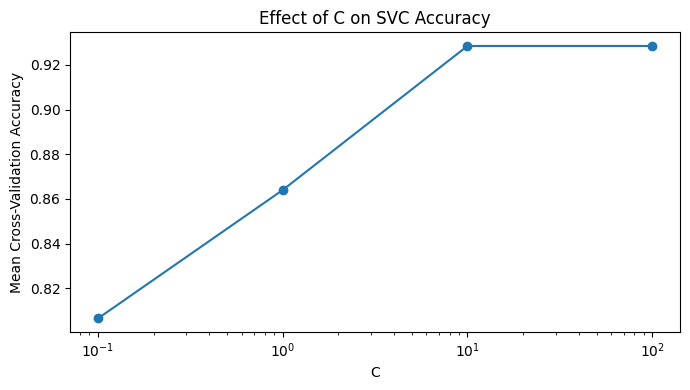

In [361]:
plt.figure(figsize=(7,4))
plt.plot(c_results_df["C"], c_results_df["Mean Accuracy"], marker='o')
plt.xscale("log")
plt.title("Effect of C on SVC Accuracy")
plt.xlabel("C")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.tight_layout()
plt.show()

<h3 id="hyperparameter-2">Hyperparameter 2: Kernel</h3>
<a href="#top">Back to top</a>

In [362]:
kernel_values = ['linear', 'rbf', 'poly']
kernel_results = []

for kernel in kernel_values:
    svc_model = SVC(C=1, kernel=kernel, random_state=43)
    scores = cross_val_score(svc_model, tfidf_fs1, y, cv=5, scoring='accuracy')
    
    kernel_results.append({
        "Kernel": kernel,
        "Mean Accuracy": round(scores.mean(), 4),
        "Std Dev": round(scores.std(), 4)
    })

kernel_results_df = pd.DataFrame(kernel_results)
kernel_results_df

,Kernel,Mean Accuracy,Std Dev
0,linear,0.8640,0.0117
1,rbf,0.9516,0.0112
2,poly,0.9239,0.0140


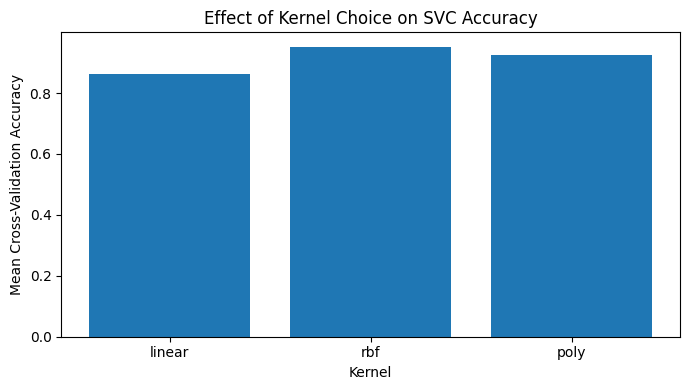

In [363]:
#Bar chart to compare kernel performance
plt.figure(figsize=(7,4))
plt.bar(kernel_results_df["Kernel"], kernel_results_df["Mean Accuracy"])
plt.title("Effect of Kernel Choice on SVC Accuracy")
plt.xlabel("Kernel")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.tight_layout()
plt.show()

In [364]:
#Based on the results, the best performing model is SVC with C=10 and RBF kernel.
best_svc = SVC(C=10, kernel='rbf', random_state=43)
tuned_scores = cross_val_score(best_svc, tfidf_fs1, y, cv=5, scoring='accuracy')

print("Best tuned model mean accuracy:", round(tuned_scores.mean(), 4))
print("Best tuned model std dev:", round(tuned_scores.std(), 4))

Best tuned model mean accuracy: 0.9631
Best tuned model std dev: 0.0135


The final tuned SVC model was created using the best-performing hyperparameter combination identified during cross-validation.